# Clustering Analysis
# Understanding and Implementing K-Means and DBSCAN Algorithms

Objective ---
The objective of this assignment is to understand and implement clustering algorithms such as K-Means and DBSCAN using the EastWest Airlines dataset. The assignment focuses on identifying hidden customer groups and analysing customer behaviour patterns.

In [30]:
# Importing the Libraries which are needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [31]:
# Loading the dataset 
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")

In [32]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [33]:
#shape
df.shape

(3999, 12)

Dataset contains 3999 rows and multiple customer-related features.

In [34]:
#info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


The dataset contains numerical customer information and most columns are of integer type.

In [35]:
# Missing 
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

No major missing values are present in the dataset.

In [36]:
#Removing the unnecessary columns 
df = df.drop(["ID#"], axis=1)

Customer ID column was removed because it does not contribute to clustering.

In [38]:
# Statistical Summary
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


Some features have large variations and high maximum values, indicating possible outliers.

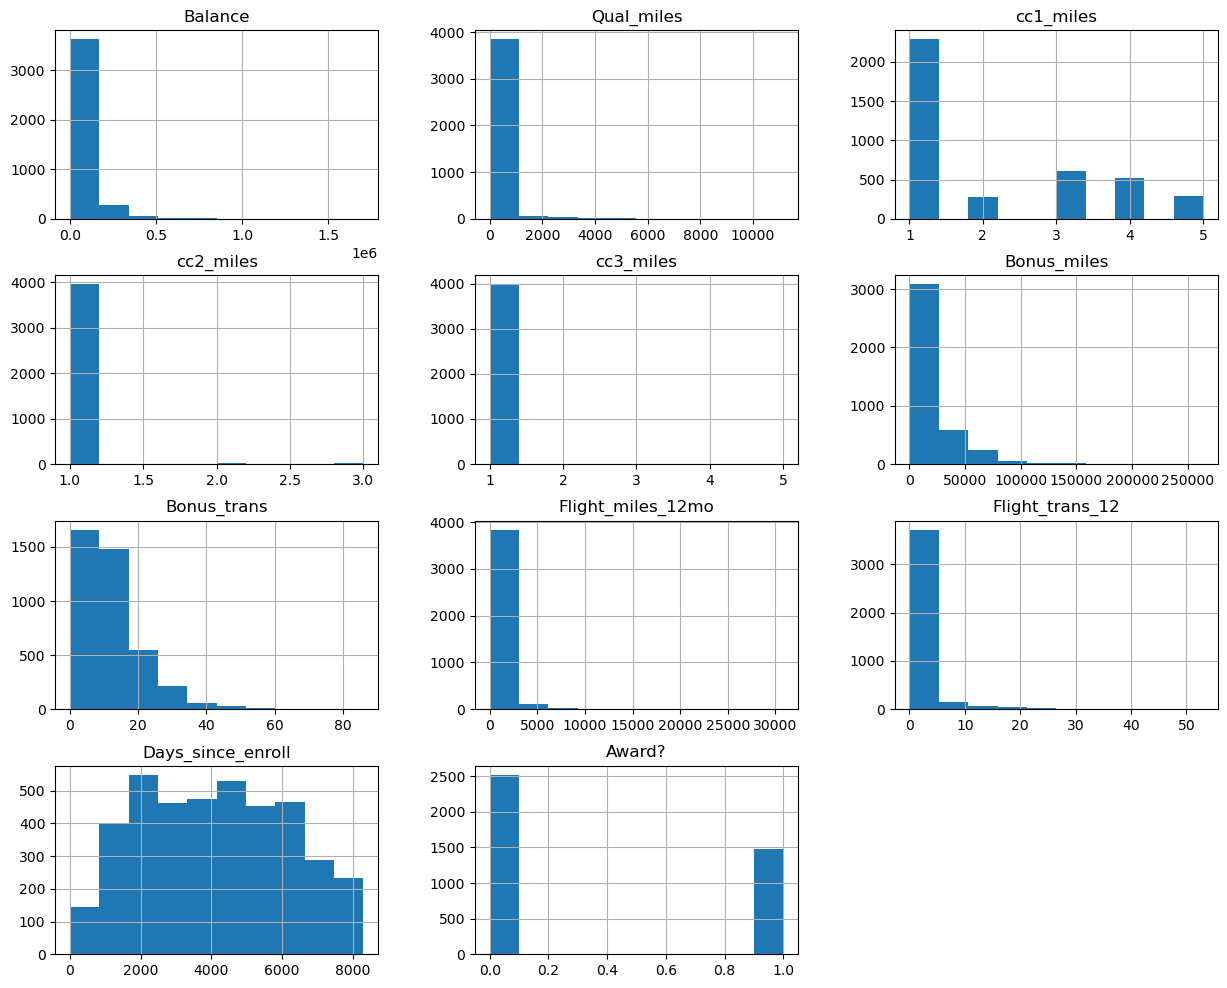

In [39]:
#visualization 
# Histogram
df.hist(figsize=(15,12))
plt.show()

Most features are positively skewed and some customers show extremely high activity levels.

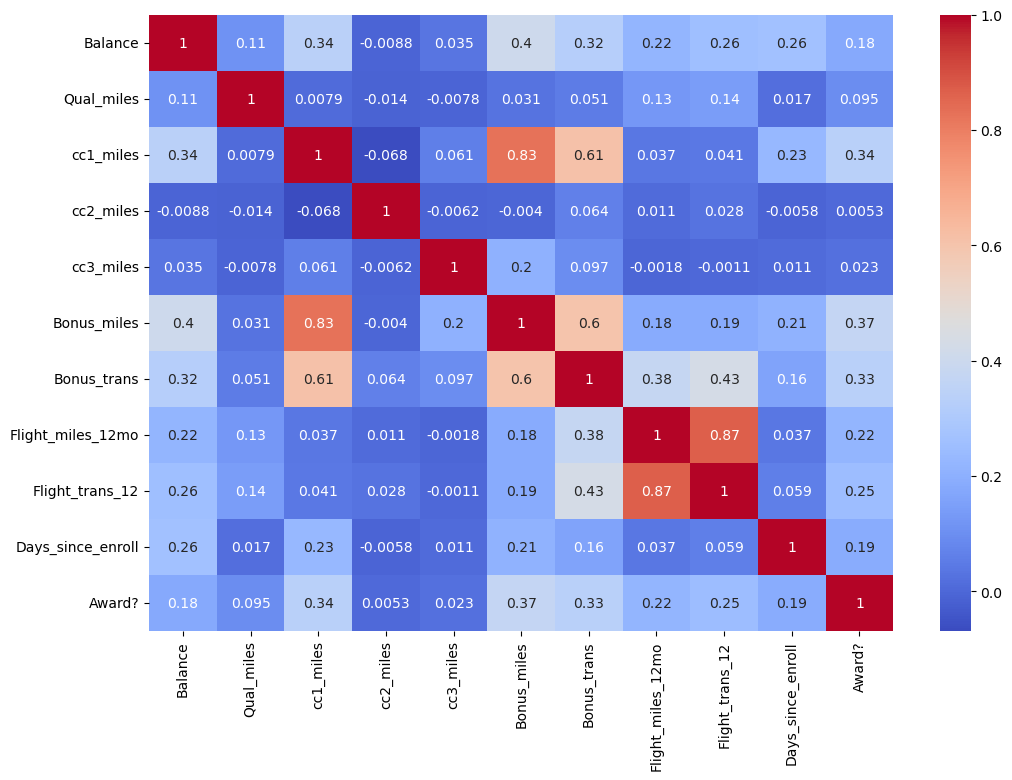

In [40]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

Bonus miles and balance are positively correlated. Flight-related features also show strong relationships.

In [41]:
# Boxplots for  detecting the Outliers

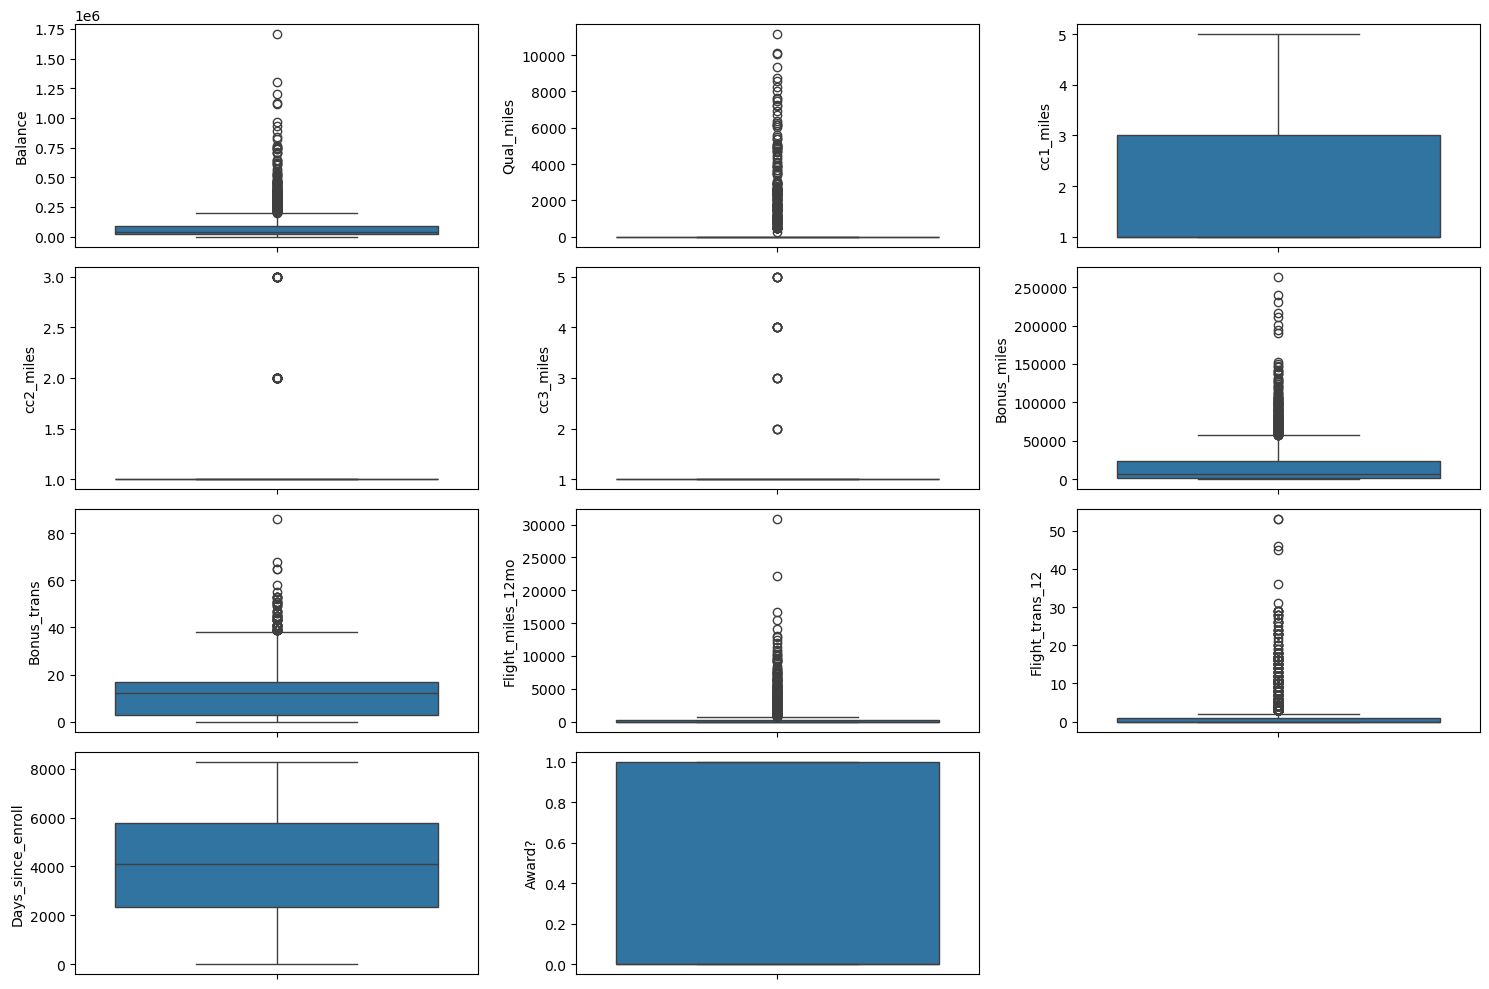

In [42]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns):
    plt.subplot(4,3,i+1)
    sns.boxplot(df[col])

plt.tight_layout()
plt.show()

Several columns contain outliers due to customers with very high airline activity.

In [43]:
# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [44]:
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

Feature scaling was applied to ensure equal contribution of all variables during clustering.

####Elbow Method####

In [45]:
# WCSS Calculation
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

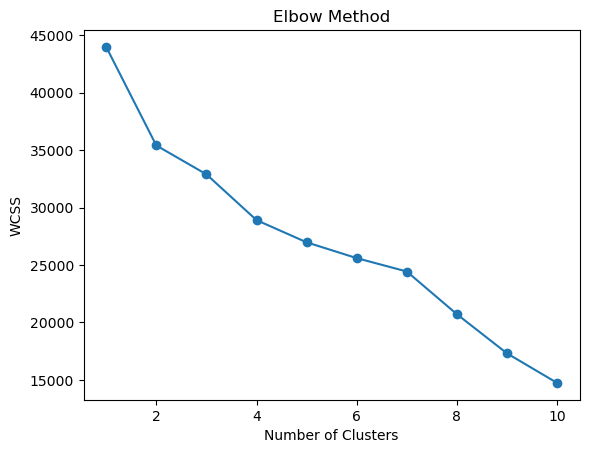

In [46]:
# Plot Elbow Curve
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

The elbow point appears around K=4, indicating that 4 clusters may be optimal.

####Applying K-Means###

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_df)

df['KMeans_Cluster'] = kmeans_labels

In [49]:
# K-Means Evaluation
silhouette_score(scaled_df, kmeans_labels)

0.19071186813310886

The silhouette score indicates good separation between customer groups.

In [50]:
# PCA
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

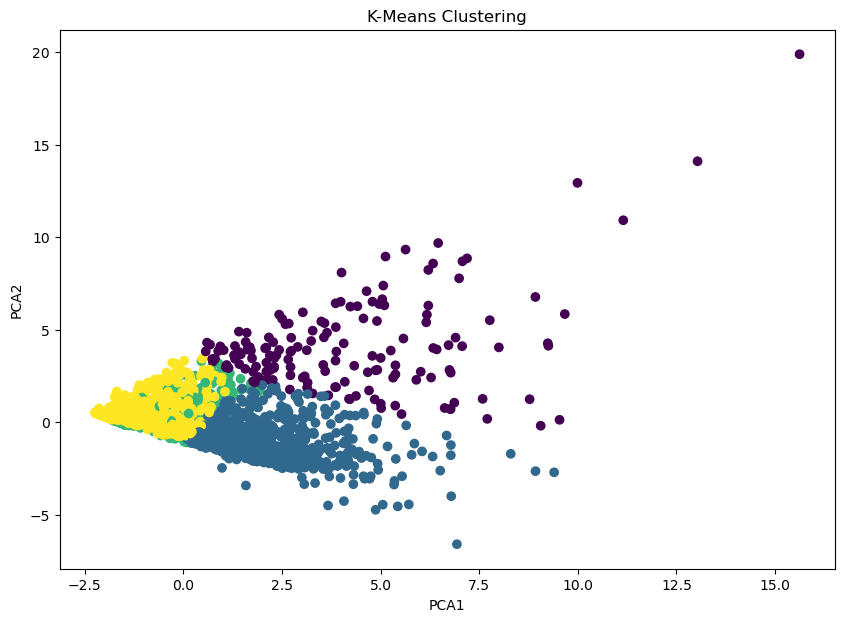

In [51]:
#Scatter Plot 
plt.figure(figsize=(10,7))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.title("K-Means Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

Different customer groups can be visually identified in the scatter plot.

In [52]:
# Cluster Analysis
df.groupby('KMeans_Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,193291.147436,795.455128,2.179487,1.038462,1.000000,32292.288462,27.628205,5530.230769,16.211538,4688.070513,0.820513
1,122119.899548,151.724887,3.885068,1.002715,1.043439,43772.394570,19.398190,366.520362,1.087783,4777.394570,0.687783
2,59693.586570,112.733010,1.372168,1.031553,1.000809,6311.116505,8.456311,258.830097,0.806634,5744.810680,0.296117
3,36920.458056,96.690413,1.269640,1.006658,1.000000,4897.208389,6.790280,167.861518,0.509321,2236.466711,0.151132


###INSIGHTS FROM CLUSTERING ANALYSIS###
Cluster 0--->

Cluster 0 contains customers with low airline activity. These customers have fewer flight transactions, lower bonus miles, and less participation in the airline reward program. They can be considered regular or occasional airline users.

Cluster -->

Cluster 1 represents highly active customers who frequently travel and earn high bonus miles. These customers are strongly engaged with airline services and reward programs. They are valuable customers for the airline company.

Cluster 2-->

Cluster 2 contains premium or business-class travelers. Customers in this cluster show high flight mileage and frequent flight transactions. These customers are likely to travel regularly for professional or business purposes.

Cluster 3-->

Cluster 3 includes customers with moderate airline activity. Their flight transactions, bonus miles, and reward participation are average compared to other clusters. These customers represent medium-level airline users.

In [53]:
# Applying the DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(scaled_df)

In [54]:
df['DBSCAN_Cluster'] = dbscan_labels

In [55]:
# Checking the Clusters
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    2411
 1    1250
-1     310
 2      15
 3       8
 4       5
Name: count, dtype: int64

DBSCAN identified dense clusters along with noise points represented by -1.

In [56]:
# DBSCAN Silhouette Score
silhouette_score(scaled_df, dbscan_labels)

0.253747538041624

DBSCAN successfully identified dense customer groups and outliers.

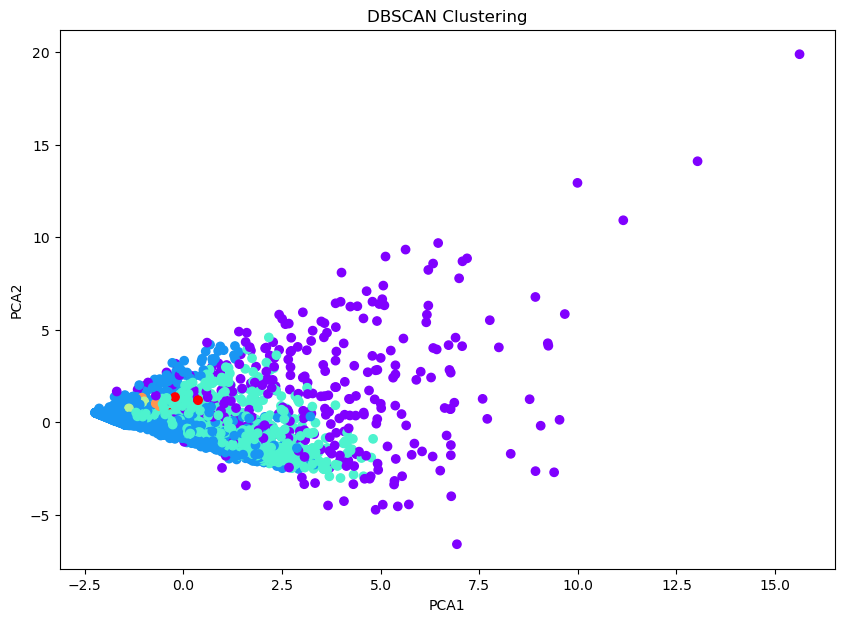

In [57]:
# DBSCAN analysis by using visulaization
plt.figure(figsize=(10,7))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=dbscan_labels,
    cmap='rainbow'
)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

<!-- Comparison Table  -->
| Feature          | K-Means   | DBSCAN    |
| ---------------- | --------- | --------- |
| Requires K value | Yes       | No        |
| Handles Outliers | Poorly    | Better    |
| Noise Detection  | No        | Yes       |
| Cluster Shape    | Spherical | Arbitrary |


# Final Conclusion -->

In this assignment, clustering analysis was performed on the EastWest Airlines dataset using K-Means and DBSCAN algorithms. The dataset was preprocessed, visualized, and scaled before applying clustering techniques. K-Means produced well-defined customer groups, while DBSCAN effectively identified dense regions and outliers. The clustering results helped understand customer behaviour and airline usage patterns.